# Student Dropout Risk Prediction
## Notebook 3 — XGBoost Model Training & Evaluation

**Prerequisites:** Run `02_preprocessing_dropout_prediction.ipynb` first.

### Objectives
- Train a baseline XGBoost classifier
- Evaluate using accuracy, precision, recall, F1, AUC-ROC
- Tune hyperparameters using cross-validation
- Train the final tuned model
- Generate dropout risk scores (probabilities)
- Save the final model for use in the Streamlit app

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import joblib
import os

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Preprocessed Data

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

FEATURE_NAMES = X_train.columns.tolist()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train — Dropout: {y_train.sum()} | Non-dropout: {(y_train==0).sum()}')
print(f'y_test  — Dropout: {y_test.sum()}  | Non-dropout: {(y_test==0).sum()}')

X_train : (4804, 45)
X_test  : (885, 45)
y_train — Dropout: 2402 | Non-dropout: 2402
y_test  — Dropout: 284  | Non-dropout: 601


---
## 2. Baseline XGBoost Model

We first train a baseline model with default parameters to establish a performance floor.

In [3]:
baseline_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

y_pred_baseline  = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print('Baseline Model Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_baseline)*100:.2f}%')
print(f'  Precision : {precision_score(y_test, y_pred_baseline)*100:.2f}%')
print(f'  Recall    : {recall_score(y_test, y_pred_baseline)*100:.2f}%')
print(f'  F1 Score  : {f1_score(y_test, y_pred_baseline)*100:.2f}%')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_proba_baseline):.4f}')

Baseline Model Results:
  Accuracy  : 89.04%
  Precision : 84.76%
  Recall    : 80.28%
  F1 Score  : 82.46%
  AUC-ROC   : 0.9291


---
## 3. Cross-Validation on Baseline

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    baseline_model, X_train, y_train,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print('5-Fold Cross-Validation (AUC-ROC):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\n  Mean  : {cv_scores.mean():.4f}')
print(f'  Std   : {cv_scores.std():.4f}')

5-Fold Cross-Validation (AUC-ROC):
  Fold 1: 0.9578
  Fold 2: 0.9623
  Fold 3: 0.9635
  Fold 4: 0.9691
  Fold 5: 0.9503

  Mean  : 0.9606
  Std   : 0.0063


---
## 4. Hyperparameter Tuning

We search over key XGBoost hyperparameters using GridSearchCV.

> **Note:** This may take 3–5 minutes depending on your machine.

In [5]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nBest parameters : {grid_search.best_params_}')
print(f'Best AUC-ROC    : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best AUC-ROC    : 0.9647


---
## 5. Train Final Tuned Model

In [6]:
best_params = grid_search.best_params_

final_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_final  = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print('Final Tuned Model Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_final)*100:.2f}%')
print(f'  Precision : {precision_score(y_test, y_pred_final)*100:.2f}%')
print(f'  Recall    : {recall_score(y_test, y_pred_final)*100:.2f}%')
print(f'  F1 Score  : {f1_score(y_test, y_pred_final)*100:.2f}%')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_proba_final):.4f}')

Final Tuned Model Results:
  Accuracy  : 89.27%
  Precision : 84.62%
  Recall    : 81.34%
  F1 Score  : 82.94%
  AUC-ROC   : 0.9338


---
## 6. Evaluation Visualisations

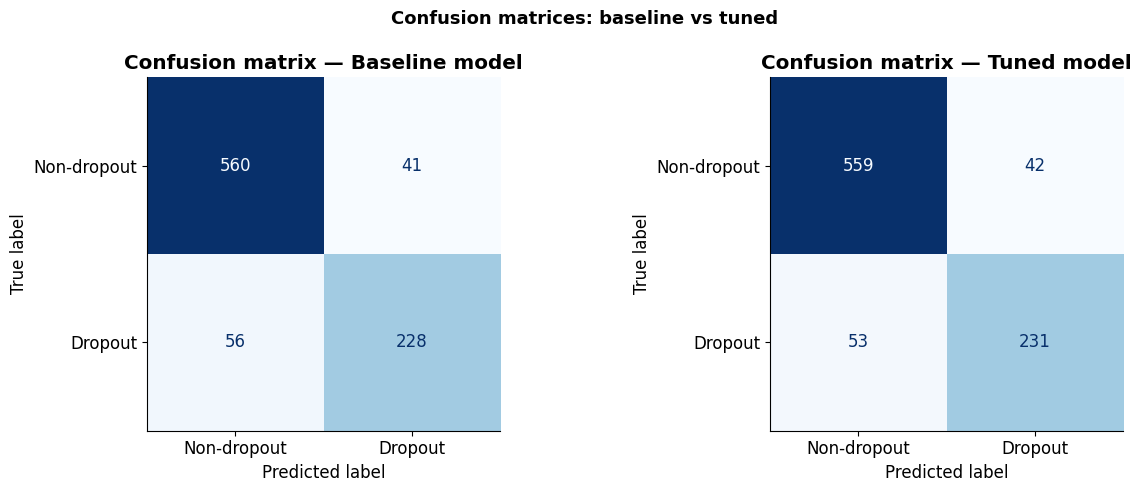

In [7]:
# ── 6a. Confusion Matrix ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (model_name, y_pred) in zip(axes, [
    ('Baseline model', y_pred_baseline),
    ('Tuned model',    y_pred_final)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-dropout', 'Dropout'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion matrix — {model_name}', fontweight='bold')

plt.suptitle('Confusion matrices: baseline vs tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

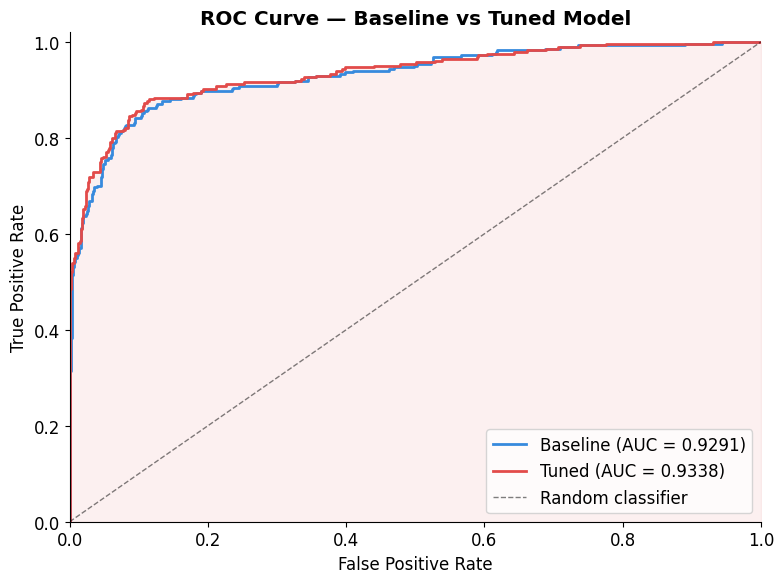

In [8]:
# ── 6b. ROC Curve ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in [
    ('Baseline', y_proba_baseline, '#378ADD'),
    ('Tuned',    y_proba_final,    '#E24B4A')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.fill_between(
    *roc_curve(y_test, y_proba_final)[:2],
    alpha=0.08, color='#E24B4A'
)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Baseline vs Tuned Model', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../data/processed/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── 6c. Classification Report ─────────────────────────────────────────────────
print('Classification Report — Final Tuned Model:')
print('=' * 55)
print(classification_report(y_test, y_pred_final,
                             target_names=['Non-dropout', 'Dropout']))

Classification Report — Final Tuned Model:
              precision    recall  f1-score   support

 Non-dropout       0.91      0.93      0.92       601
     Dropout       0.85      0.81      0.83       284

    accuracy                           0.89       885
   macro avg       0.88      0.87      0.88       885
weighted avg       0.89      0.89      0.89       885



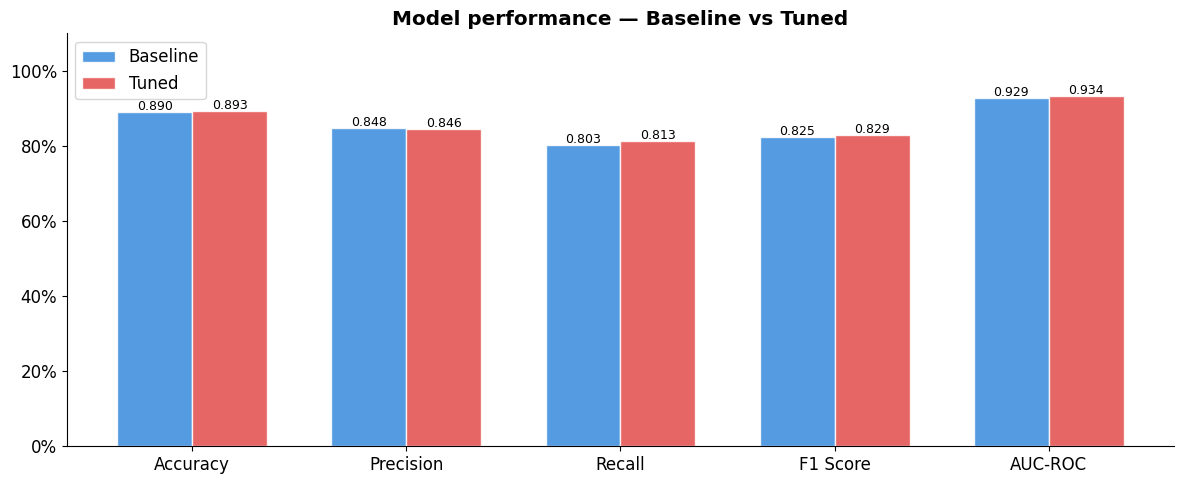

In [10]:
# ── 6d. Metrics comparison bar chart ─────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
baseline_scores = [
    accuracy_score(y_test, y_pred_baseline),
    precision_score(y_test, y_pred_baseline),
    recall_score(y_test, y_pred_baseline),
    f1_score(y_test, y_pred_baseline),
    roc_auc_score(y_test, y_proba_baseline)
]
tuned_scores = [
    accuracy_score(y_test, y_pred_final),
    precision_score(y_test, y_pred_final),
    recall_score(y_test, y_pred_final),
    f1_score(y_test, y_pred_final),
    roc_auc_score(y_test, y_proba_final)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline',
               color='#378ADD', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, tuned_scores, width, label='Tuned',
               color='#E24B4A', edgecolor='white', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Model performance — Baseline vs Tuned', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Risk Score Generation

The XGBoost `predict_proba` output (0.0 to 1.0) is our dropout risk score. We bucket it into three risk levels.

In [11]:
def assign_risk_level(score):
    if score >= 0.70:
        return 'High'
    elif score >= 0.40:
        return 'Medium'
    else:
        return 'Low'

# Apply to test set
test_results = X_test.copy()
test_results['Risk_Score']  = y_proba_final
test_results['Risk_Level']  = test_results['Risk_Score'].apply(assign_risk_level)
test_results['Actual_Label'] = y_test.values
test_results['Predicted']    = y_pred_final

print('Risk level distribution on test set:')
print(test_results['Risk_Level'].value_counts())
print()
print('Risk score statistics:')
print(test_results['Risk_Score'].describe().round(4))

Risk level distribution on test set:
Risk_Level
Low       596
High      231
Medium     58
Name: count, dtype: int64

Risk score statistics:
count    885.0000
mean       0.3259
std        0.3937
min        0.0010
25%        0.0161
50%        0.0818
75%        0.7389
max        0.9994
Name: Risk_Score, dtype: float64


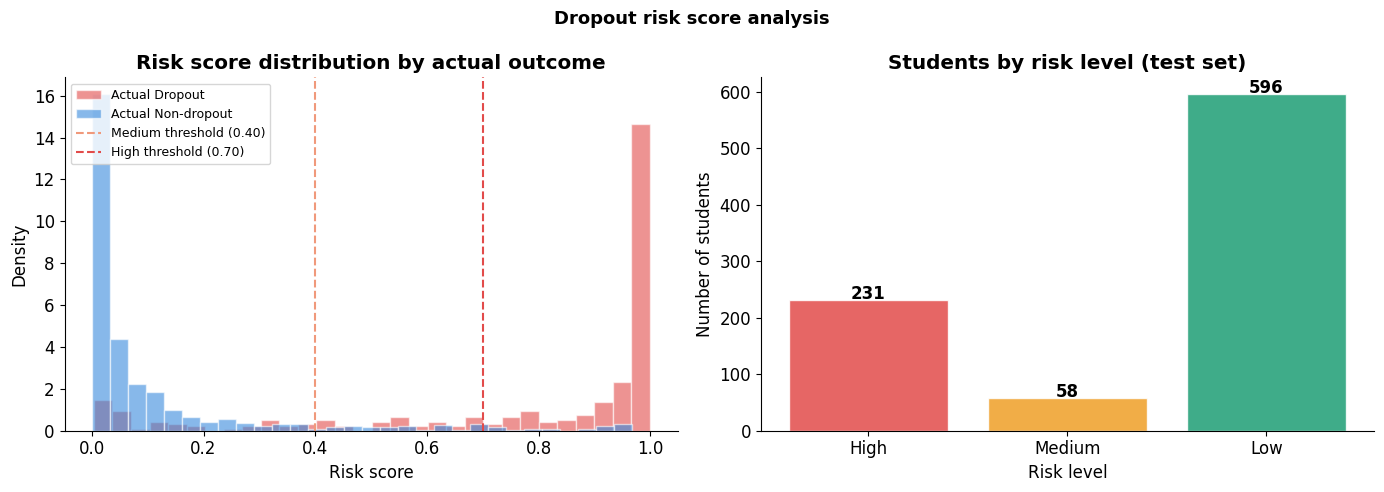

In [12]:
# Risk score distribution by actual outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, color, name in [(1, '#E24B4A', 'Actual Dropout'), (0, '#378ADD', 'Actual Non-dropout')]:
    subset = test_results[test_results['Actual_Label'] == label]['Risk_Score']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=name, edgecolor='white', density=True)

axes[0].axvline(0.40, color='#F0997B', linestyle='--', linewidth=1.5, label='Medium threshold (0.40)')
axes[0].axvline(0.70, color='#E24B4A', linestyle='--', linewidth=1.5, label='High threshold (0.70)')
axes[0].set_xlabel('Risk score')
axes[0].set_ylabel('Density')
axes[0].set_title('Risk score distribution by actual outcome', fontweight='bold')
axes[0].legend(fontsize=9)

# Risk level counts
risk_counts = test_results['Risk_Level'].value_counts().reindex(['High', 'Medium', 'Low'])
colors_risk = ['#E24B4A', '#EF9F27', '#1D9E75']
axes[1].bar(risk_counts.index, risk_counts.values, color=colors_risk, edgecolor='white', alpha=0.85)
for i, v in enumerate(risk_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[1].set_title('Students by risk level (test set)', fontweight='bold')
axes[1].set_xlabel('Risk level')
axes[1].set_ylabel('Number of students')

plt.suptitle('Dropout risk score analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Feature Importance (Built-in XGBoost)

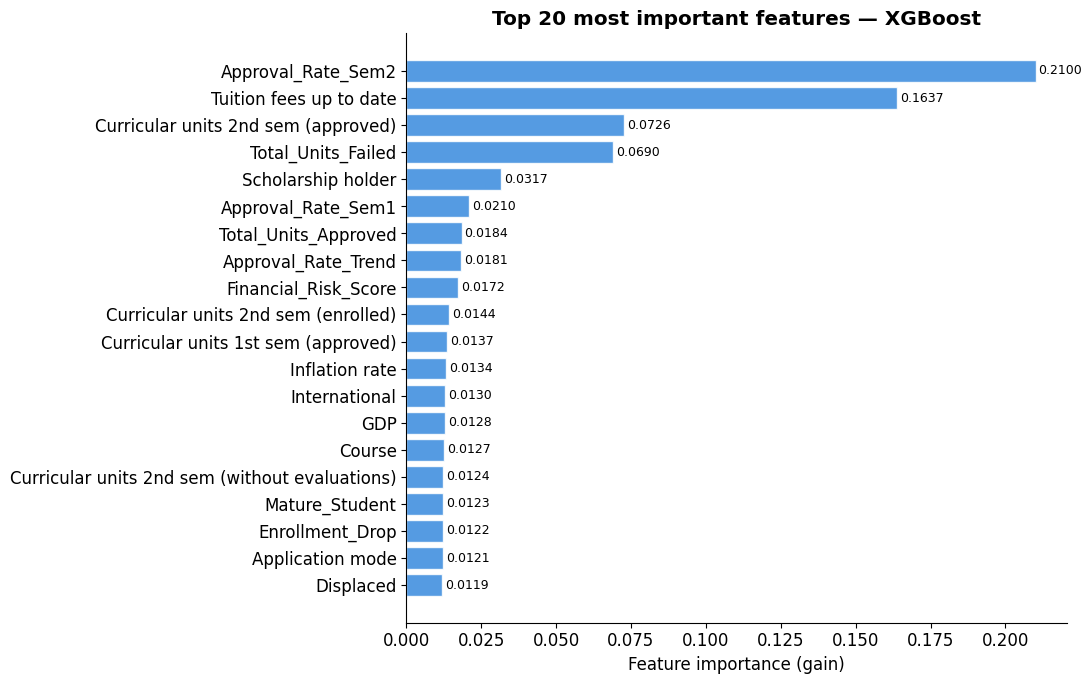

Top 10 features:
                            Feature  Importance
                 Approval_Rate_Sem2    0.210050
            Tuition fees up to date    0.163702
Curricular units 2nd sem (approved)    0.072567
                 Total_Units_Failed    0.069004
                 Scholarship holder    0.031680
                 Approval_Rate_Sem1    0.020974
               Total_Units_Approved    0.018426
                Approval_Rate_Trend    0.018128
               Financial_Risk_Score    0.017239
Curricular units 2nd sem (enrolled)    0.014370


In [13]:
importance_df = pd.DataFrame({
    'Feature'   : FEATURE_NAMES,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

top_20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_20['Feature'][::-1], top_20['Importance'][::-1],
               color='#378ADD', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, top_20['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature importance (gain)')
ax.set_title('Top 20 most important features — XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(importance_df.head(10).to_string(index=False))

---
## 9. Save Model & Results

In [14]:
# Save final trained model
joblib.dump(final_model, '../models/xgboost_model.pkl')
print('Model saved to ../models/xgboost_model.pkl')

# Save feature importance
importance_df.to_csv('../data/processed/feature_importance.csv', index=False)
print('Feature importance saved.')

# Save test results with risk scores
test_results.to_csv('../data/processed/test_predictions.csv', index=False)
print('Test predictions with risk scores saved.')

# Save best parameters
joblib.dump(best_params, '../models/best_params.pkl')
print('Best parameters saved.')

# Save the assign_risk_level function config
risk_config = {'low_threshold': 0.40, 'high_threshold': 0.70}
joblib.dump(risk_config, '../models/risk_config.pkl')
print('Risk config saved.')

Model saved to ../models/xgboost_model.pkl
Feature importance saved.
Test predictions with risk scores saved.
Best parameters saved.
Risk config saved.


---
## 10. Final Model Summary

In [15]:
print('=' * 60)
print('  FINAL MODEL SUMMARY')
print('=' * 60)
print(f"""
Model        : XGBoost Classifier
Best params  : {best_params}

Test set performance
  Accuracy   : {accuracy_score(y_test, y_pred_final)*100:.2f}%
  Precision  : {precision_score(y_test, y_pred_final)*100:.2f}%
  Recall     : {recall_score(y_test, y_pred_final)*100:.2f}%
  F1 Score   : {f1_score(y_test, y_pred_final)*100:.2f}%
  AUC-ROC    : {roc_auc_score(y_test, y_proba_final):.4f}

Risk levels (test set)
  High risk  (>=0.70) : {(test_results['Risk_Level']=='High').sum()} students
  Medium risk (0.40-0.70): {(test_results['Risk_Level']=='Medium').sum()} students
  Low risk   (<0.40)  : {(test_results['Risk_Level']=='Low').sum()} students

Top 5 predictive features
""")
print(importance_df.head(5)[['Feature', 'Importance']].to_string(index=False))
print(f"""
Saved artifacts
  ../models/xgboost_model.pkl
  ../models/best_params.pkl
  ../models/risk_config.pkl
  ../data/processed/test_predictions.csv
  ../data/processed/feature_importance.csv

Next step -> Notebook 04: SHAP analysis
""")
print('=' * 60)

  FINAL MODEL SUMMARY

Model        : XGBoost Classifier
Best params  : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}

Test set performance
  Accuracy   : 89.27%
  Precision  : 84.62%
  Recall     : 81.34%
  F1 Score   : 82.94%
  AUC-ROC    : 0.9338

Risk levels (test set)
  High risk  (>=0.70) : 231 students
  Medium risk (0.40-0.70): 58 students
  Low risk   (<0.40)  : 596 students

Top 5 predictive features

                            Feature  Importance
                 Approval_Rate_Sem2    0.210050
            Tuition fees up to date    0.163702
Curricular units 2nd sem (approved)    0.072567
                 Total_Units_Failed    0.069004
                 Scholarship holder    0.031680

Saved artifacts
  ../models/xgboost_model.pkl
  ../models/best_params.pkl
  ../models/risk_config.pkl
  ../data/processed/test_predictions.csv
  ../data/processed/feature_importance.csv

Next step -> Notebook 04: SHAP analysis

